In [1]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

data = load_digits()
print(data.keys())
print(data['target'])

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
[0 1 2 ... 8 9 8]


#### "First thing, grab a piece of paper and visually classify those 25 digits. We'll see if you're better or worse than a computer!"

In [5]:
### My Guesses

by_hand = [[8,9,8,1,2,6,9],
           [4,9,4,0,6,1,7],
           [6,9,5,4,4,8,4],
           [0,5,6,4,7,9,3],
           [2,4,0,8,3,9,6],
           [1,4,2,5,5,4,4],
           [9,6,2,6,8,0,0]]

In [17]:
### Forensic Informatics: Finding the Seed (just for fun, it's a brute force attempt)

from sklearn import datasets
from numba import njit
dGerosa_targets = np.array([8,9,8,-1,-1,6,9,
                         -1,9,-1,0,6,-1,7,
                         6,9,5,4,-1,8,4,
                         0,5,6,-1,-1,9,3,
                         2,-1,0,8,3,9,6,
                         -1,8,-1,0,5,4,-1,
                         9,6,-1,6,-1,0,0])

# -1 stands for "Sorry, I really don't know what that is"

digits = datasets.load_digits()
targets = digits.target
        
M = 1000000
def filter_seed(idx, seed_storage):
    if seed_storage == None:
        seed_storage = []
        for seed in range(M):
            np.random.seed(seed)
            mask = ( dGerosa_targets == -1 )
            my_targets = np.random.choice(digits.target, 49)
            my_targets[mask] = -1
            if np.array_equal(my_targets[:idx], dGerosa_targets[:idx]) == True:
                seed_storage.append(seed)
                #print('Maybe! -> ', seed)
        return seed_storage
    
    i = 0
    for seed in seed_storage:
        np.random.seed(seed)
        mask = ( dGerosa_targets == -1 )
        my_targets = np.random.choice(digits.target, 49)
        my_targets[mask] = -1
        if np.array_equal(my_targets[:idx], dGerosa_targets[:idx]) == True:
            print('Maybe! ->', seed)
            i+=1
        if np.array_equal(my_targets[:idx], dGerosa_targets[:idx]) == False:
            seed_storage = np.delete(seed_storage, i)
    return seed_storage

seed_3 = filter_seed(3, None)
seed_7 = filter_seed(7, seed_3)
        

# esempio seed buoni per iniziare con 8,9,8
# seed_3 = [961, 3081, 4321, 4670, 5764, 6946, 9225, 10083,
#             12707, 14201, 14888, 15326, 19054, 19196, 19885, 
#             20130, 20381, 21668, 22123, 22189, 22378, 22764,
#             23646, 24280, 25858, 26149, 26545, 27749, 28001,
#             28867, 29201, 29237, 30898, 32773, 35522, 36270, 
#             36534, 36975, 37525, 37606, 38108, 39225, 39334, 
#             41141, 41375, 43887, 44373, 46142, 47304, 47993, 
#             48856, 54769, 55134, 55138, 55325, 55495, 57714, 
#             57741, 60235, 61898, 64356, 67016, 67838, 69874, 
#             70058, 72061, 73133, 73169, 73432, 74833, 78605, 79443]

print(seed_7)
# esempio seed buoni per 8,9,8,-1,-1,6,9 ( filtrati da seed_3 sopra )
# seed_7 = [4321, 176697, 346925, 411406, 463832, 524767, 539352, 555936]

Maybe! -> 4321
Maybe! -> 176697
Maybe! -> 346925
Maybe! -> 411406
Maybe! -> 463832
Maybe! -> 524767
Maybe! -> 539352
Maybe! -> 555936
Maybe! -> 855209
Maybe! -> 864779
Maybe! -> 952810
[  4321 176697 346925 411406 463832 524767 539352 555936 855209 864779
 952810]


#### Time to check how I performed "by eye"

Actual Data     [8 9 8 1 2 6 9 1 9 4 0 6 1 7 6 9 5 4 4 8 4 0 5 6 8 9 9 3 2 1 0 8 3 9 6 1 1
 2 0 5 4 4 9 6 2 6 1 0 0]
My Guess by Eye [8 9 8 1 2 6 9 4 9 4 0 6 1 7 6 9 5 4 4 8 4 0 5 6 4 7 9 3 2 4 0 8 3 9 6 1 4
 2 5 5 4 4 9 6 2 6 8 0 0]
Success Rate:  85.714 %


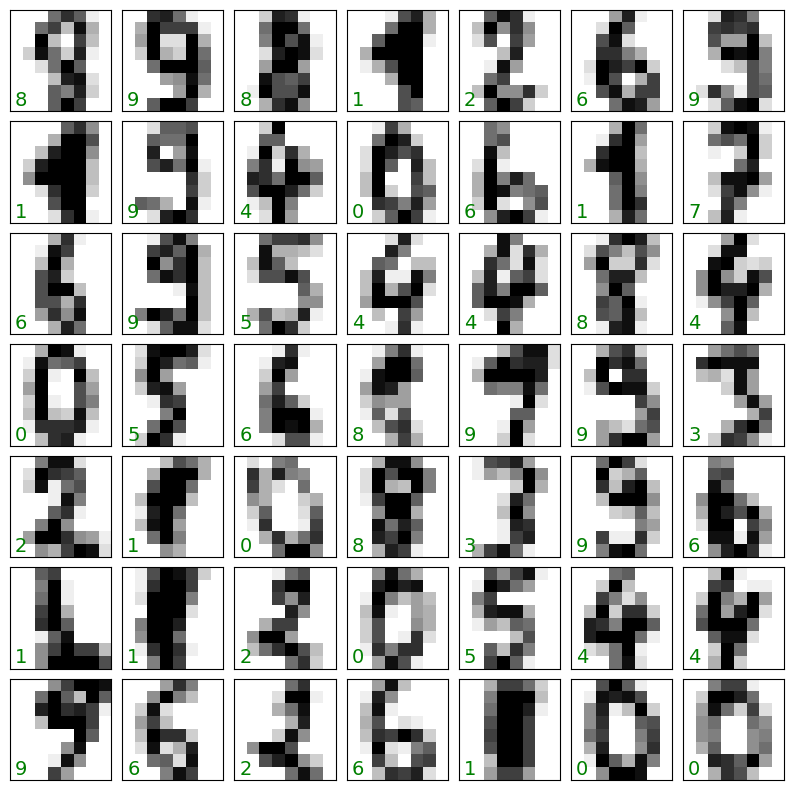

In [18]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(4321) ## I lucked out and it was the first one, ok!
### print(np.shape(data['data']))
idx = np.random.choice(np.arange(0,1797,1), 49)
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

mychoices = idx#np.random.choice(data.images.shape[0], 100)

for i, ax in enumerate(axes.flat):
    ax.imshow((data.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(data.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

print('Actual Data    ', data.target[mychoices])
print('My Guess by Eye', np.ravel(by_hand))
success = len(np.ravel(by_hand))
for ii, jj in zip(data.target[mychoices], np.ravel(by_hand)):
    if ii != jj: success-=1
print('Success Rate: ', np.around(success/len(np.ravel(by_hand))*100,3), '%')

#### Use the unsupervised dimensionality reduction technique called Isomap. 
#### Have a look at the Isomap documentation and reduce the MINST dataset. 
#### Do some plots to visualize your results

C:\Users\alfac\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\alfac\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


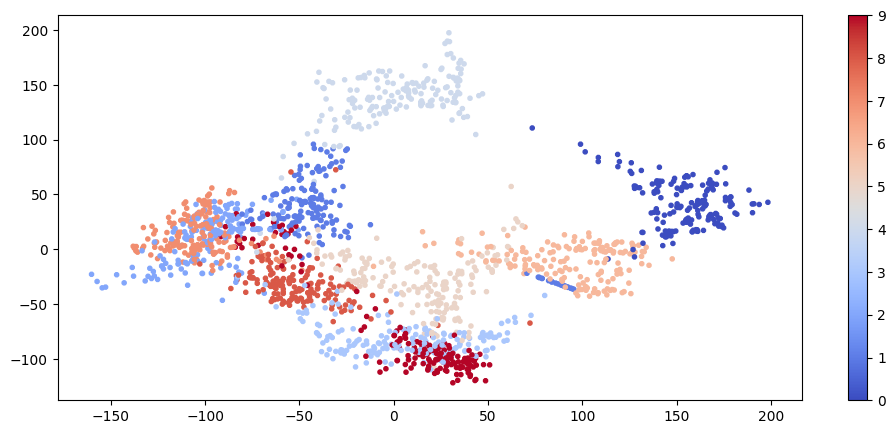

In [23]:
from sklearn.manifold import Isomap
X, _ = load_digits(return_X_y = True)
embedding = Isomap(n_components=2)
idx = np.arange(0, 1764, 1)
X_transf = embedding.fit_transform(X[idx])
plt.figure(figsize=(12,5))
plt.scatter(X_transf[:,0], X_transf[:,1], c=data['target'][idx], cmap='coolwarm', s=10, marker='8')
plt.colorbar()

#### Split the dataset taking 80% of the images as tranining dataset and leaving the other 20% as a validation set.

In [24]:
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LogisticRegression as LR

data = load_digits()
Xtrain, Xtest, y_train, y_test = tts(data['data'], data['target'], test_size=0.2, train_size=0.8)
# yTrain, yTest = tts(data['target'], test_size=0.2, train_size=0.8)
# print(np.shape(Xtrain)[0], np.shape(Xtest)[0])

#### Use a simple Logistic Regression which despite its name is a common classification algorithm.
#### Use the flag solver='sag'

In [25]:
model = LR(solver='sag')
model.fit(Xtrain, y_train)
yPredict = model.predict(Xtest)

C:\Users\alfac\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


#### Compute the accuracy (sklearn.metrics.accuracy_score) of your emulator. 
#### In this context, accuracy is simply the fraction of the digits that were correctly identified. 
#### Compute the accuracy on both the training and the validation set. 
#### Comment on the results.

In [26]:
from sklearn.metrics import accuracy_score
print('Predicting the Training Set:', 100*accuracy_score(y_train, model.predict(Xtrain), normalize=True), '%')
print('Predicting the Test Set:', 100*accuracy_score(y_test, yPredict, normalize=True), '%')

Predicting the Training Set: 100.0 %
Predicting the Test Set: 96.38888888888889 %


Of course, using "predict" on the training set leads to 100% accuracy. This comes as no surprise, as the model was trained on it.

On the other hand, if I want to generalize my model to new data, I get a lower than 100% accuracy score. Rightfully so!

#### The accuracy is a single number doesn't tell us where we've gone wrong. 
#### Plot the confusion matrix as we did above. 
#### What are the digits that are more challenging to identify, does it make sense?

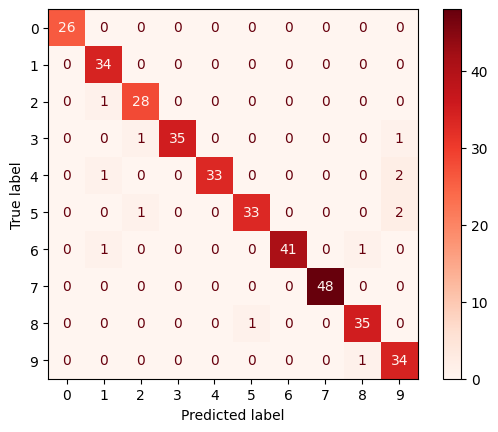

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
CM = confusion_matrix(y_test, yPredict)
ConfusionMatrixDisplay.from_estimator(model, Xtest, y_test, cmap='Reds') #, norm=True) #(CM)
plt.show()

Yes, this confusion matrix makes sense. It seems that number 9 loves being mistaken for a lot of other numbers!